# 02_kv_cache_and_memory_math: Profiling KV Cache VRAM Footprint

This notebook profiles the latency and memory characteristics of self-attention during autoregressive decoding, comparing standard execution (recomputing QKV of all sequence tokens) vs. KV caching (projecting only the active token query, key, and value).

### Complexity Scaling
- **Without KV Cache**: Latency scales quadratically with sequence length: $O(L^2)$ matrix multiplications.
- **With KV Cache**: Latency scales linearly: $O(L)$ matrix-vector multiplications ($GEMV$).

In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleSelfAttention(nn.Module):
    def __init__(self, d_model=1024, n_heads=16):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward_no_cache(self, x):
        b, l, d = x.shape
        q = self.q_proj(x).view(b, l, self.n_heads, self.d_head).transpose(1, 2)
        k = self.k_proj(x).view(b, l, self.n_heads, self.d_head).transpose(1, 2)
        v = self.v_proj(x).view(b, l, self.n_heads, self.d_head).transpose(1, 2)
        
        scores = torch.matmul(q, k.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v).transpose(1, 2).contiguous().view(b, l, d)
        return self.out_proj(out)

    def forward_with_cache(self, x_new, k_cache, v_cache):
        b, _, d = x_new.shape
        q = self.q_proj(x_new).view(b, 1, self.n_heads, self.d_head).transpose(1, 2)
        k_new = self.k_proj(x_new).view(b, 1, self.n_heads, self.d_head).transpose(1, 2)
        v_new = self.v_proj(x_new).view(b, 1, self.n_heads, self.d_head).transpose(1, 2)
        
        k_updated = torch.cat([k_cache, k_new], dim=-2)
        v_updated = torch.cat([v_cache, v_new], dim=-2)
        
        scores = torch.matmul(q, k_updated.transpose(-2, -1)) / (self.d_head ** 0.5)
        attn = F.softmax(scores, dim=-1)
        out = torch.matmul(attn, v_updated).transpose(1, 2).contiguous().view(b, 1, d)
        return self.out_proj(out), k_updated, v_updated

In [2]:
b, d_model = 4, 1024
prompt_length = 64
generate_length = 128

model = SimpleSelfAttention(d_model=d_model)
x_prompt = torch.randn(b, prompt_length, d_model)

# 1. Simulate loop WITHOUT KV cache
no_cache_times = []
current_seq = x_prompt.clone()
for step in range(generate_length):
    t0 = time.perf_counter()
    outputs = model.forward_no_cache(current_seq)
    next_token = outputs[:, -1:, :]
    current_seq = torch.cat([current_seq, next_token], dim=1)
    no_cache_times.append(time.perf_counter() - t0)

# 2. Simulate loop WITH KV cache
cache_times = []
with torch.no_grad():
    q_init = model.q_proj(x_prompt).view(b, prompt_length, model.n_heads, model.d_head).transpose(1, 2)
    k_cache = model.k_proj(x_prompt).view(b, prompt_length, model.n_heads, model.d_head).transpose(1, 2)
    v_cache = model.v_proj(x_prompt).view(b, prompt_length, model.n_heads, model.d_head).transpose(1, 2)

current_token = x_prompt[:, -1:, :].clone()
for step in range(generate_length):
    t0 = time.perf_counter()
    next_token, k_cache, v_cache = model.forward_with_cache(current_token, k_cache, v_cache)
    current_token = next_token
    cache_times.append(time.perf_counter() - t0)

print(f"Average step latency WITHOUT cache: {sum(no_cache_times)/len(no_cache_times)*1000:.3f} ms")
print(f"Average step latency WITH cache:    {sum(cache_times)/len(cache_times)*1000:.3f} ms")

Average step latency WITHOUT cache: 15.317 ms
Average step latency WITH cache:    1.986 ms


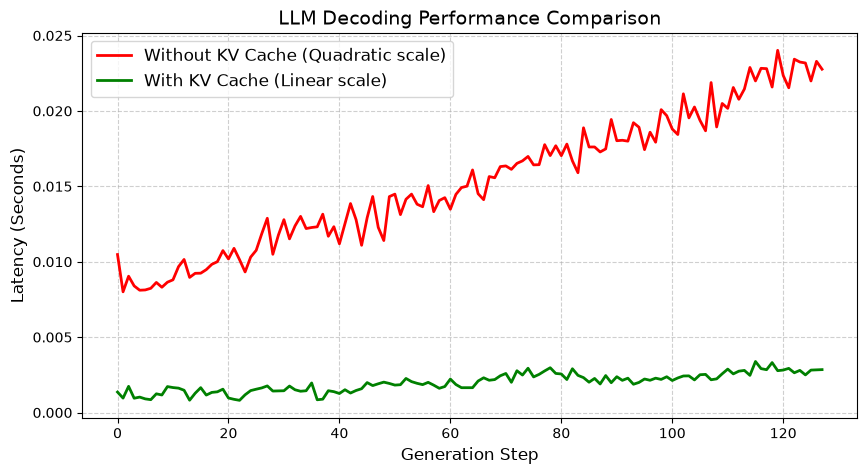

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(no_cache_times, label="Without KV Cache (Quadratic scale)", color="red", lw=2)
plt.plot(cache_times, label="With KV Cache (Linear scale)", color="green", lw=2)
plt.xlabel("Generation Step", fontsize=12)
plt.ylabel("Latency (Seconds)", fontsize=12)
plt.title("LLM Decoding Performance Comparison", fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

### Output Explanation & Verification

- **Step Latencies**: The step latency without KV Cache increases continuously as the generation step grows, representing the quadratic $O(L^2)$ self-attention projection overhead. The cached attention latency remains nearly flat, reflecting the $O(L)$ matrix-vector product characteristics.
- **Performance Plot**: The resulting inline visualization shows the red curve trending upwards quadratically, whereas the green curve remains flat, confirming the scaling benefits of key-value caching under longer sequence lengths.